In [1]:
# =============================================================================
# 🚖 Predict the Fare Amount of Future Rides Using Regression Analysis
# Component 2 – Data Preprocessing and Exploration
# Mentorship Project | MentorMind × Uber
# Name : Sonushaw
# Date : April 27, 2026
# =============================================================================

In [2]:
# ── 1. Import Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [5]:
# ── 2. Load and Explore the Dataset ──────────────────────────────────────────
# Download dataset from: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset
# Place uber.csv in the same folder as this script before running

df = pd.read_csv('uber.csv')

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(df.head())
print(df.info())
print(df.describe())

Dataset shape : 200,000 rows × 9 columns
Memory usage  : 40.94 MB
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003       7.5000   
1    27835199    2009-07-17 20:04:56.0000002       7.7000   
2    44984355   2009-08-24 21:45:00.00000061      12.9000   
3    25894730    2009-06-26 08:22:21.0000001       5.3000   
4    17610152  2014-08-28 17:47:00.000000188      16.0000   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC          -73.9998          40.7384   
1  2009-07-17 20:04:56 UTC          -73.9944          40.7282   
2  2009-08-24 21:45:00 UTC          -74.0050          40.7408   
3  2009-06-26 08:22:21 UTC          -73.9761          40.7908   
4  2014-08-28 17:47:00 UTC          -73.9250          40.7441   

   dropoff_longitude  dropoff_latitude  passenger_count  
0           -73.9995           40.7232                1  
1           -73.9947           40.7503                1  
2 

                   Missing Count  Missing %
dropoff_longitude              1     0.0000
dropoff_latitude               1     0.0000


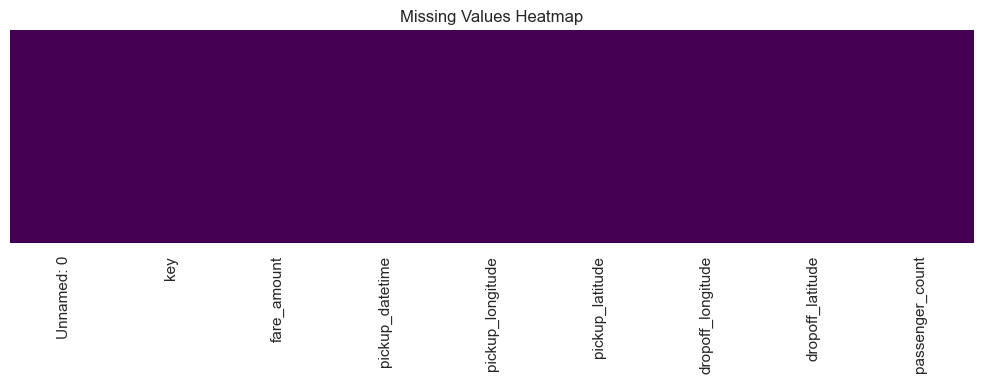

Shape after dropping NaNs : (199999, 9)
Remaining nulls           : 0


In [6]:
# ── 3. Handle Missing Data ────────────────────────────────────────────────────
# Count and percentage of missing values per column
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# Heatmap of missing value locations
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

# Drop rows with any missing values (missing fraction is small)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape after dropping NaNs : {df.shape}")
print(f"Remaining nulls           : {df.isnull().sum().sum()}")

In [7]:
# ── 4. Feature Engineering ────────────────────────────────────────────────────

# 4a. Parse datetime and extract time-based features
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df['hour']        = df['pickup_datetime'].dt.hour       # 0-23
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['month']       = df['pickup_datetime'].dt.month      # 1-12
df['year']        = df['pickup_datetime'].dt.year

df.dropna(subset=['pickup_datetime'], inplace=True)
print(f"Shape after datetime parsing: {df.shape}")

# 4b. Haversine distance (km) between pickup and dropoff
def haversine(lat1, lon1, lat2, lon2):
    """
    Returns great-circle distance in km between two GPS coordinates.
    Formula: https://en.wikipedia.org/wiki/Haversine_formula
    """
    R = 6371  # Earth's mean radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi        = np.radians(lat2 - lat1)
    dlambda     = np.radians(lon2 - lon1)
    a = (np.sin(dphi / 2) ** 2
         + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)
print(df[['pickup_latitude','pickup_longitude',
          'dropoff_latitude','dropoff_longitude','distance_km']].head())

# 4c. Remove outliers and logically invalid records
df = df[(df['fare_amount'] >= 1)      & (df['fare_amount'] <= 500)]
df = df[(df['passenger_count'] >= 1)  & (df['passenger_count'] <= 6)]
df = df[(df['distance_km'] > 0.1)     & (df['distance_km'] <= 200)]

# Bounding box: New York City
df = df[
    df['pickup_latitude'].between(40.4, 41.0)   &
    df['pickup_longitude'].between(-74.5, -72.8) &
    df['dropoff_latitude'].between(40.4, 41.0)   &
    df['dropoff_longitude'].between(-74.5, -72.8)
]
df.reset_index(drop=True, inplace=True)
print(f"Shape after all cleaning steps: {df.shape}")

Shape after datetime parsing: (199999, 13)
   pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude  \
0          40.7384          -73.9998           40.7232           -73.9995   
1          40.7282          -73.9944           40.7503           -73.9947   
2          40.7408          -74.0050           40.7726           -73.9626   
3          40.7908          -73.9761           40.8033           -73.9653   
4          40.7441          -73.9250           40.7612           -73.9731   

   distance_km  
0       1.6833  
1       2.4576  
2       5.0364  
3       1.6617  
4       4.4754  
Shape after all cleaning steps: (191839, 14)


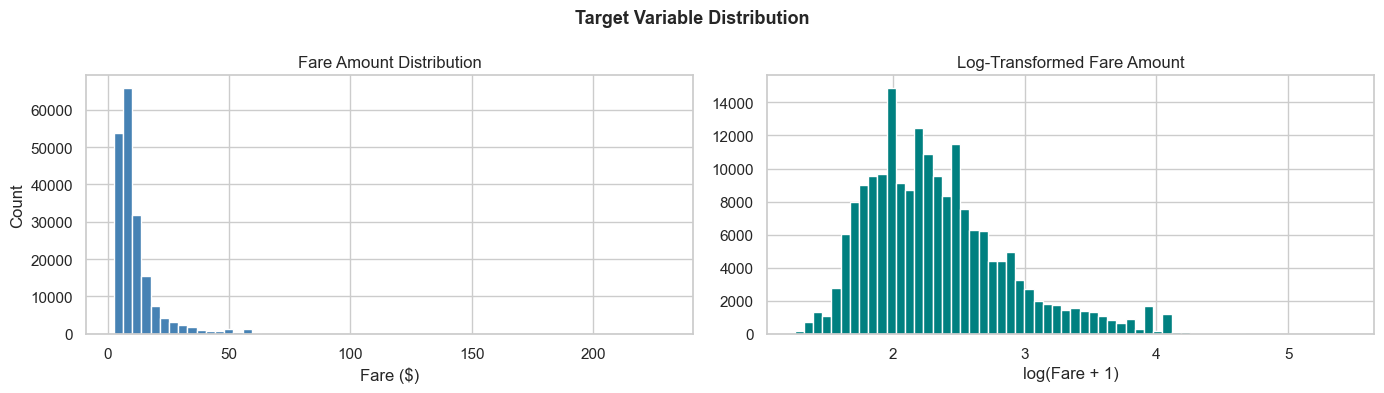

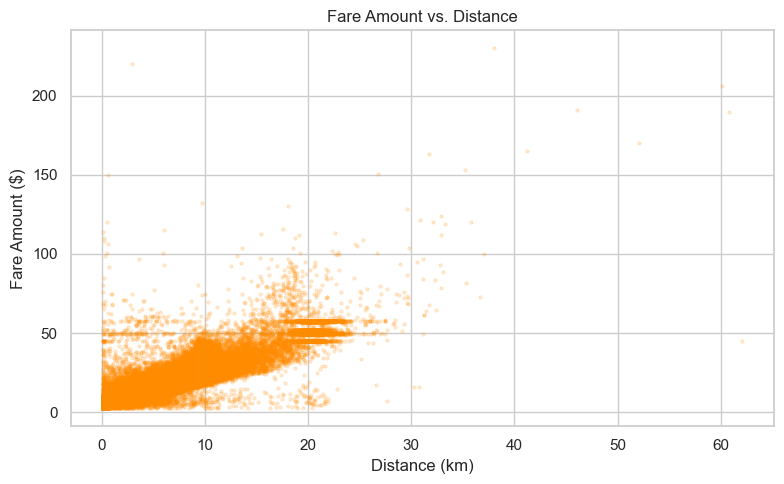

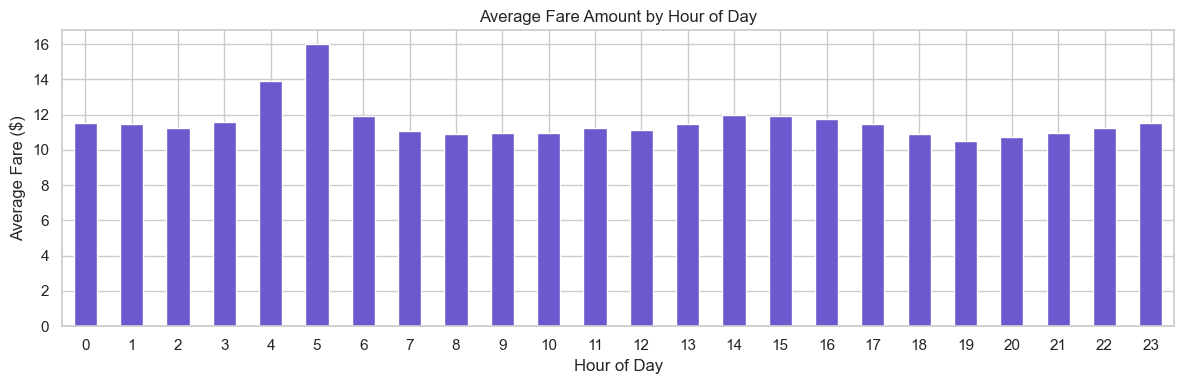

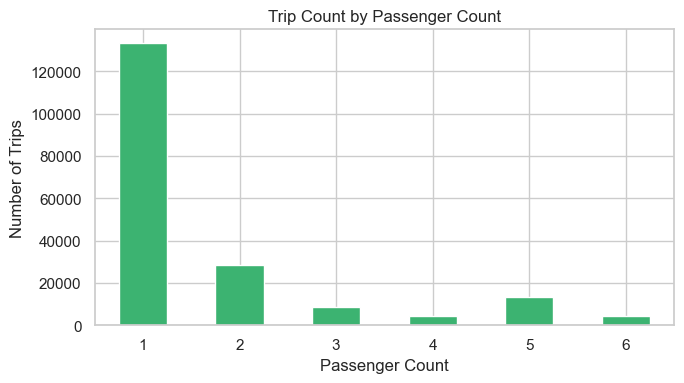

In [8]:
# ── 5. Exploratory Data Analysis (EDA) ───────────────────────────────────────

# Fare amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['fare_amount'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Fare Amount Distribution')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Count')
axes[1].hist(np.log1p(df['fare_amount']), bins=60, color='teal', edgecolor='white')
axes[1].set_title('Log-Transformed Fare Amount')
axes[1].set_xlabel('log(Fare + 1)')
plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Fare vs Distance
plt.figure(figsize=(8, 5))
plt.scatter(df['distance_km'], df['fare_amount'], alpha=0.15, s=5, color='darkorange')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.title('Fare Amount vs. Distance')
plt.tight_layout()
plt.show()

# Average fare by hour of day
hourly_avg = df.groupby('hour')['fare_amount'].mean()
plt.figure(figsize=(12, 4))
hourly_avg.plot(kind='bar', color='slateblue', edgecolor='white')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare ($)')
plt.title('Average Fare Amount by Hour of Day')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Passenger count distribution
plt.figure(figsize=(7, 4))
df['passenger_count'].value_counts().sort_index().plot(
    kind='bar', color='mediumseagreen', edgecolor='white')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Trips')
plt.title('Trip Count by Passenger Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# ── 6. Split the Dataset ──────────────────────────────────────────────────────
FEATURES = ['distance_km', 'passenger_count', 'hour', 'day_of_week', 'month', 'year']
TARGET   = 'fare_amount'

X = df[FEATURES]
y = df[TARGET]

# 80% training / 20% testing, fixed seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Full dataset  : {len(df):,} samples")
print(f"Training set  : {len(X_train):,} samples  ({len(X_train)/len(df)*100:.0f}%)")
print(f"Test set      : {len(X_test):,} samples  ({len(X_test)/len(df)*100:.0f}%)")

Full dataset  : 191,839 samples
Training set  : 153,471 samples  (80%)
Test set      : 38,368 samples  (20%)


In [10]:
# ── 7. Data Scaling / Normalisation ──────────────────────────────────────────
# StandardScaler: zero mean, unit variance
# IMPORTANT: fit on training data only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES)

print("Scaled train — mean (should be ≈ 0):")
print(X_train_scaled.mean().round(4))
print("\nScaled train — std  (should be ≈ 1):")
print(X_train_scaled.std().round(4))

Scaled train — mean (should be ≈ 0):
distance_km       -0.0000
passenger_count   -0.0000
hour               0.0000
day_of_week        0.0000
month             -0.0000
year              -0.0000
dtype: float64

Scaled train — std  (should be ≈ 1):
distance_km       1.0000
passenger_count   1.0000
hour              1.0000
day_of_week       1.0000
month             1.0000
year              1.0000
dtype: float64


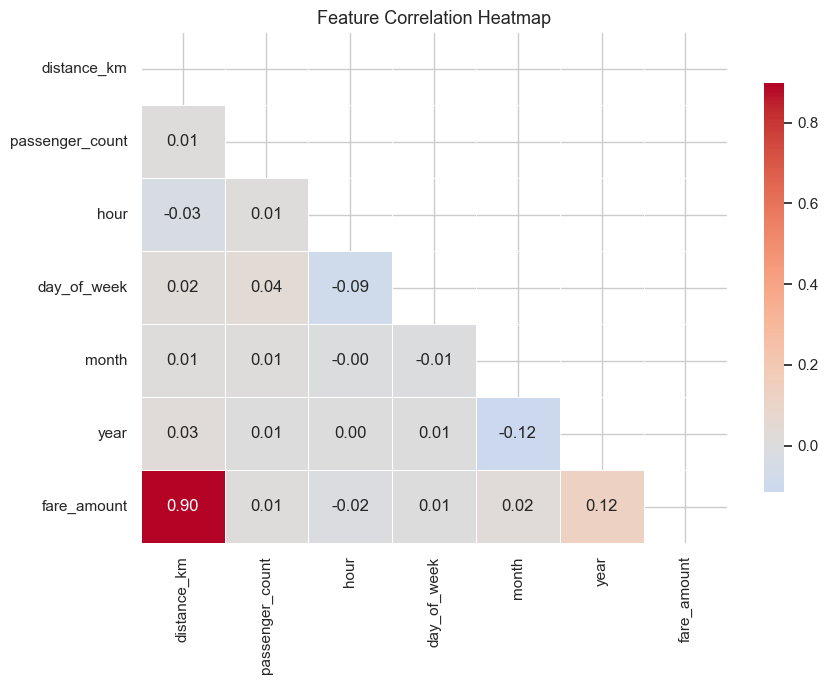

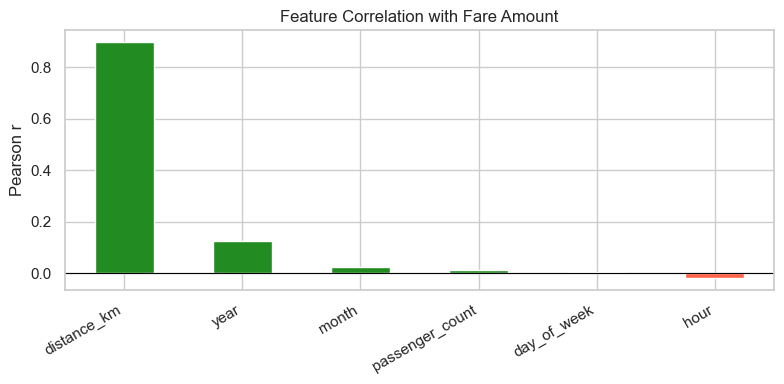


Feature correlations with fare_amount:
distance_km        0.8969
year               0.1249
month              0.0249
passenger_count    0.0136
day_of_week        0.0052
hour              -0.0199


In [11]:
# ── 8. Correlation Analysis ───────────────────────────────────────────────────
corr_cols   = FEATURES + [TARGET]
corr_matrix = df[corr_cols].corr()

# Heatmap
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

# Bar chart of correlations with fare_amount
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
colors = ['forestgreen' if v > 0 else 'tomato' for v in target_corr]
plt.figure(figsize=(8, 4))
target_corr.plot(kind='bar', color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Fare Amount')
plt.ylabel('Pearson r')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\nFeature correlations with fare_amount:")
print(target_corr.to_string())

In [12]:
# ── 9. Summary ────────────────────────────────────────────────────────────────
print("""
✅ Component 2 Complete — Summary
==================================
Step 1 : Imported all required libraries
Step 2 : Loaded dataset, explored shape, dtypes, statistics
Step 3 : Handled missing values (heatmap + drop)
Step 4 : Feature engineering — Haversine distance + datetime features + cleaning
Step 5 : EDA — 4 visualisation plots
Step 6 : Train-test split (80/20, random_state=42)
Step 7 : StandardScaler normalisation (fit on train only)
Step 8 : Correlation heatmap and bar chart

Next → Component 3: Model Building (Linear Regression, Evaluation)
""")


✅ Component 2 Complete — Summary
Step 1 : Imported all required libraries
Step 2 : Loaded dataset, explored shape, dtypes, statistics
Step 3 : Handled missing values (heatmap + drop)
Step 4 : Feature engineering — Haversine distance + datetime features + cleaning
Step 5 : EDA — 4 visualisation plots
Step 6 : Train-test split (80/20, random_state=42)
Step 7 : StandardScaler normalisation (fit on train only)
Step 8 : Correlation heatmap and bar chart

Next → Component 3: Model Building (Linear Regression, Evaluation)

